Используем устройство: cuda

==================== Обучаем ODE Модель ====================


ODE Эпоха 5/5: 100%|██████████| 156/156 [00:04<00:00, 37.86it/s, loss=0.000953]



==================== Обучаем Стандартную Модель ====================


STD Эпоха 5/5: 100%|██████████| 156/156 [00:00<00:00, 389.63it/s, loss=0.00109]



==================== Результаты Сравнения ====================

Ожидаемый паттерн: 1 2 3 4 5 6 7 8 10 11 12...
ODE Модель сгенерировала: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14]
STD Модель сгенерировала: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14]

Визуализируем карты внимания...


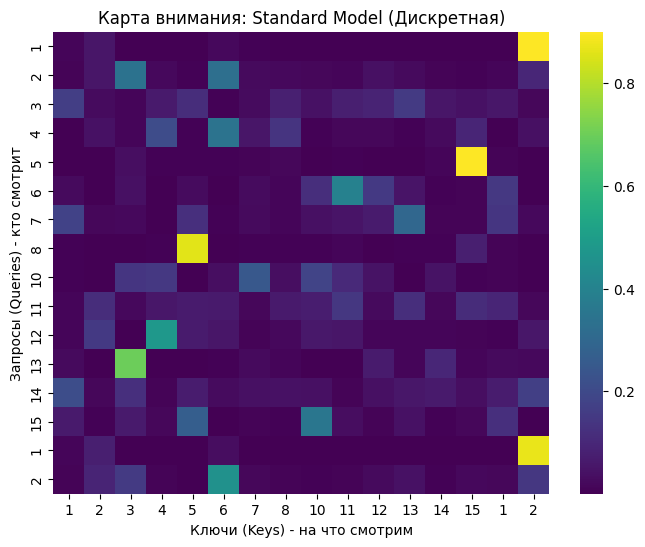

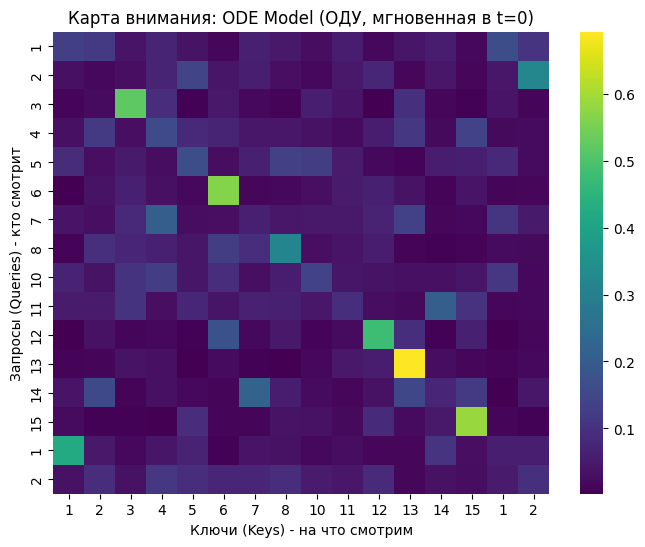

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Проверяем, доступна ли torchdiffeq и GPU
try:
    from torchdiffeq import odeint_adjoint as odeint
except ImportError:
    print("torchdiffeq не установлена. Установите: pip install torchdiffeq")
    from torchdiffeq import odeint

# --- 1. Гиперпараметры и конфигурация ---
VOCAB_SIZE = 20
EMBEDDING_DIM = 64
SEQ_LENGTH = 16
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EPOCHS = 5

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используем устройство: {device}")


# --- 2. Подготовка данных ---
def create_synthetic_data(num_samples=5000):
    pattern1 = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8])
    pattern2 = torch.tensor([10, 11, 12, 13, 14, 15])
    data = []
    for _ in range(num_samples // (len(pattern1) + len(pattern2))):
        data.extend(pattern1)
        data.extend(pattern2)
    data = torch.tensor(data, dtype=torch.long)
    inputs, targets = [], []
    for i in range(len(data) - SEQ_LENGTH):
        inputs.append(data[i : i + SEQ_LENGTH])
        targets.append(data[i + 1 : i + SEQ_LENGTH + 1])
    inputs = torch.stack(inputs)
    targets = torch.stack(targets)
    dataset = TensorDataset(inputs, targets)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    return dataloader


# --- 3. Определение моделей ---

# 3.1 Компоненты внимания


# Функция производной для ОДУ-внимания
class ODEAttentionFunc(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        # Нормализация применяется к входу функции, как это принято в Neural ODE
        self.layer_norm = nn.LayerNorm(embedding_dim)
        self.to_query = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.to_key = nn.Linear(embedding_dim, embedding_dim, bias=False)

    def forward(self, t, h):
        h_norm = self.layer_norm(h)
        Q = self.to_query(h_norm)
        K = self.to_key(h_norm)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (
            self.embedding_dim**0.5
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        # Взаимодействие частиц: взвешенная сумма разниц векторов
        h_diff = h.unsqueeze(1) - h.unsqueeze(2)
        dh_dt = (attention_weights.unsqueeze(-1) * h_diff).sum(dim=2)
        return dh_dt


# Блок ОДУ-внимания, который будет интегрирован в общую модель
class ODEAttentionBlock(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.ode_func = ODEAttentionFunc(embedding_dim)
        self.integration_time = torch.tensor([0, 1], dtype=torch.float32)

    def forward(self, x):
        integration_time = self.integration_time.to(x.device)
        # Решаем ОДУ. h0 - начальное состояние (входной тензор x)
        h_trajectory = odeint(
            self.ode_func, x, integration_time, method="dopri5", atol=1e-3, rtol=1e-3
        )
        # Возвращаем конечное состояние системы h(t=1)
        return h_trajectory[1]


# Блок стандартного внимания
class StandardAttentionBlock(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.to_qkv = nn.Linear(embedding_dim, embedding_dim * 3, bias=False)
        self.out_proj = nn.Linear(embedding_dim, embedding_dim)
        self.attention_weights = None  # Для визуализации

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(B, T, D), qkv)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (D**0.5)
        self.attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(self.attention_weights, v)
        output = self.out_proj(output)
        return output


# 3.2 Базовая модель и её наследники


class BaseLanguageModel(nn.Module):
    """
    Базовый класс, содержащий общую для всех моделей архитектуру.
    """

    def __init__(self, vocab_size, embedding_dim, seq_length):
        super().__init__()
        self.seq_length = seq_length
        # Общие слои для всех моделей
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding = nn.Embedding(seq_length, embedding_dim)

        # Блок внимания - будет определен в дочерних классах
        self.attention_block = self._create_attention_block(embedding_dim)

        # Общая архитектура в стиле Transformer-блока
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.ReLU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
        )
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.lm_head = nn.Linear(embedding_dim, vocab_size)

    def _create_attention_block(self, embedding_dim):
        # Должен быть переопределен в дочернем классе
        raise NotImplementedError

    def _apply_attention(self, x):
        # Должен быть переопределен в дочернем классе
        raise NotImplementedError

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos = torch.arange(0, T, device=idx.device)
        pos_emb = self.position_embedding(pos)
        x = tok_emb + pos_emb

        # --- Ключевое различие ---
        # Применяем блок внимания (реализация зависит от дочернего класса)
        x = self._apply_attention(x)
        # ------------------------

        # Общий для всех моделей Feed-Forward блок с остаточным соединением
        x = x + self.ffn(self.norm2(x))

        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            logits_flat = logits.view(B * T, -1)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss

    @torch.no_grad()
    def generate(self, start_idx, max_new_tokens):
        self.eval()
        idx = start_idx
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.seq_length :]
            logits, _ = self.forward(idx_cond)
            logits_last = logits[:, -1, :]
            probs = F.softmax(logits_last, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx


class ODELanguageModel(BaseLanguageModel):
    def _create_attention_block(self, embedding_dim):
        return ODEAttentionBlock(embedding_dim)

    def _apply_attention(self, x):
        # Для ОДУ нет остаточного соединения `x + ...`,
        # так как выход интегратора `h(1)` уже является обновленным состоянием.
        return self.attention_block(self.norm1(x))


class StandardLanguageModel(BaseLanguageModel):
    def _create_attention_block(self, embedding_dim):
        return StandardAttentionBlock(embedding_dim)

    def _apply_attention(self, x):
        # Классический Transformer: остаточное соединение + внимание
        return x + self.attention_block(self.norm1(x))


# --- 4. Функция для визуализации ---
def visualize_attention(model, sentence_tensor, model_name="Model"):
    model.eval()
    model.to("cpu")
    sentence_tensor = sentence_tensor.to("cpu")
    attention_map = None

    with torch.no_grad():
        # Подготовка входа для блока внимания
        tok_emb = model.token_embedding(sentence_tensor)
        pos = torch.arange(0, sentence_tensor.shape[1], device=sentence_tensor.device)
        pos_emb = model.position_embedding(pos)
        x = tok_emb + pos_emb
        x_norm = model.norm1(x)

        if isinstance(model, StandardLanguageModel):
            _ = model.attention_block(x_norm)  # Прогоняем для вычисления весов
            attention_map = (
                model.attention_block.attention_weights.squeeze(0).cpu().numpy()
            )
            title = f"Карта внимания: {model_name} (Дискретная)"

        elif isinstance(model, ODELanguageModel):
            # Получаем мгновенную карту внимания в t=0
            ode_func = model.attention_block.ode_func
            h_norm = ode_func.layer_norm(x_norm)  # Используем вход блока внимания
            Q = ode_func.to_query(h_norm)
            K = ode_func.to_key(h_norm)
            scores = torch.matmul(Q, K.transpose(-2, -1)) / (
                ode_func.embedding_dim**0.5
            )
            attention_map = F.softmax(scores, dim=-1).squeeze(0).cpu().numpy()
            title = f"Карта внимания: {model_name} (ОДУ, мгновенная в t=0)"

    if attention_map is not None:
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            attention_map,
            cmap="viridis",
            xticklabels=sentence_tensor[0].tolist(),
            yticklabels=sentence_tensor[0].tolist(),
        )
        plt.title(title)
        plt.xlabel("Ключи (Keys) - на что смотрим")
        plt.ylabel("Запросы (Queries) - кто смотрит")
        plt.show()


# --- 5. Основной блок ---
if __name__ == "__main__":
    train_loader = create_synthetic_data()

    print("\n" + "=" * 20 + " Обучаем ODE Модель " + "=" * 20)
    ode_model = ODELanguageModel(VOCAB_SIZE, EMBEDDING_DIM, SEQ_LENGTH).to(device)
    optimizer_ode = torch.optim.AdamW(ode_model.parameters(), lr=LEARNING_RATE)
    for epoch in range(EPOCHS):
        ode_model.train()
        progress_bar = tqdm(train_loader, desc=f"ODE Эпоха {epoch+1}/{EPOCHS}")
        for xb, yb in progress_bar:
            xb, yb = xb.to(device), yb.to(device)
            _, loss = ode_model(xb, yb)
            optimizer_ode.zero_grad(set_to_none=True)
            loss.backward()
            optimizer_ode.step()
            progress_bar.set_postfix(loss=loss.item())

    print("\n" + "=" * 20 + " Обучаем Стандартную Модель " + "=" * 20)
    std_model = StandardLanguageModel(VOCAB_SIZE, EMBEDDING_DIM, SEQ_LENGTH).to(device)
    optimizer_std = torch.optim.AdamW(std_model.parameters(), lr=LEARNING_RATE)
    for epoch in range(EPOCHS):
        std_model.train()
        progress_bar = tqdm(train_loader, desc=f"STD Эпоха {epoch+1}/{EPOCHS}")
        for xb, yb in progress_bar:
            xb, yb = xb.to(device), yb.to(device)
            _, loss = std_model(xb, yb)
            optimizer_std.zero_grad(set_to_none=True)
            loss.backward()
            optimizer_std.step()
            progress_bar.set_postfix(loss=loss.item())

    print("\n" + "=" * 20 + " Результаты Сравнения " + "=" * 20)
    start_context = torch.tensor([[1, 2, 3, 4, 5, 6, 7]], dtype=torch.long)

    ode_generated = ode_model.generate(start_context.to(device), max_new_tokens=20)
    std_generated = std_model.generate(start_context.to(device), max_new_tokens=20)

    print(f"\nОжидаемый паттерн: 1 2 3 4 5 6 7 8 10 11 12...")
    print("ODE Модель сгенерировала:", ode_generated.cpu().tolist()[0])
    print("STD Модель сгенерировала:", std_generated.cpu().tolist()[0])

    print("\nВизуализируем карты внимания...")
    test_sentence_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 1, 2]
    test_sentence = torch.tensor([test_sentence_list], dtype=torch.long)

    visualize_attention(std_model, test_sentence, "Standard Model")
    visualize_attention(ode_model, test_sentence, "ODE Model")